# House Price Prediction

## Notebook 6 — Final Evaluation

### Objectives

- Load the best trained model
- Evaluate model performance
- Visualize predictions
- Analyze residuals
- Perform cross-validation
- Generate feature importance
- Save final outputs

Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    cross_val_score,
    KFold,
    learning_curve
)

plt.style.use("ggplot")

Paths

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"

FIGURES.mkdir(parents=True, exist_ok=True)

Load Data

In [3]:
X_train = pd.read_csv(PROCESSED / "X_train.csv")
X_valid = pd.read_csv(PROCESSED / "X_valid.csv")

y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze()
y_valid = pd.read_csv(PROCESSED / "y_valid.csv").squeeze()

Load Best Model

In [4]:
best_model = joblib.load(
    MODELS / "best_xgboost.pkl"
)

Predictions

In [5]:
predictions = best_model.predict(X_valid)

Evaluation Metrics

In [6]:
rmse = np.sqrt(
    mean_squared_error(y_valid, predictions)
)

mae = mean_absolute_error(
    y_valid,
    predictions
)

r2 = r2_score(
    y_valid,
    predictions
)

metrics = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2"],
    "Value": [rmse, mae, r2]
})

metrics

,Metric,Value
0,RMSE,26397.782937
1,MAE,16499.982422
2,R2,0.909151


Save Metrics

In [7]:
metrics.to_csv(
    REPORTS / "final_metrics.csv",
    index=False
)

Actual vs Predicted

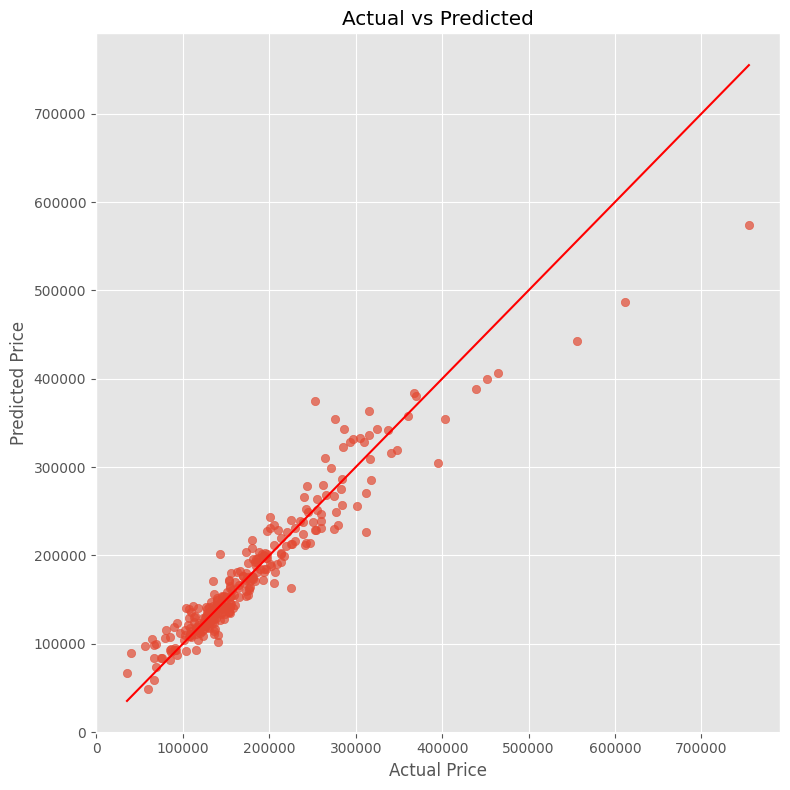

In [8]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_valid,
    predictions,
    alpha=0.7
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.tight_layout()

plt.savefig(
    FIGURES / "actual_vs_predicted.png",
    dpi=300
)

plt.show()

Residuals

In [9]:
residuals = y_valid - predictions

Residual Distribution

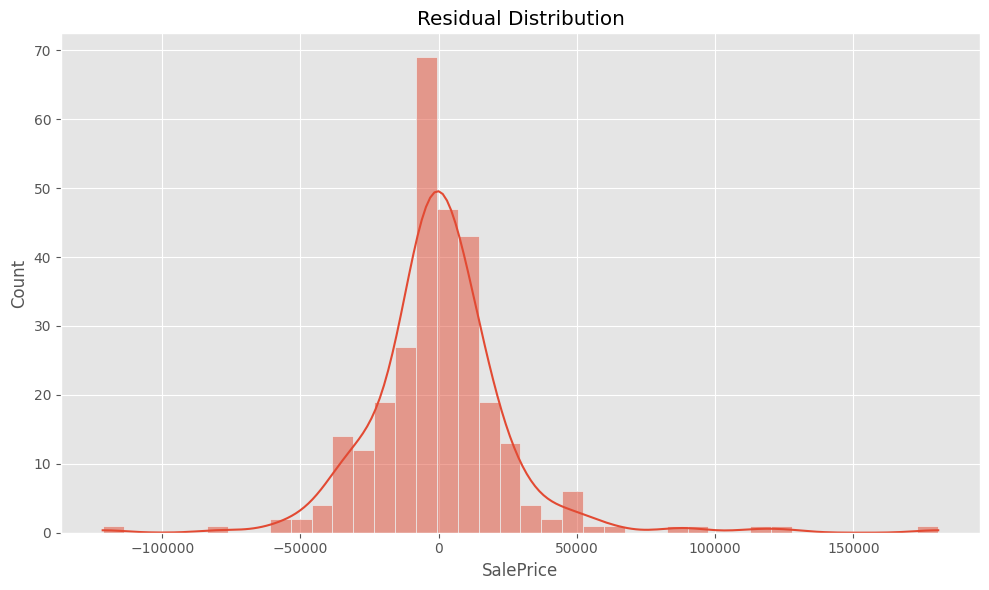

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.title("Residual Distribution")

plt.tight_layout()

plt.savefig(
    FIGURES / "residual_distribution.png",
    dpi=300
)

plt.show()

Residual Scatter

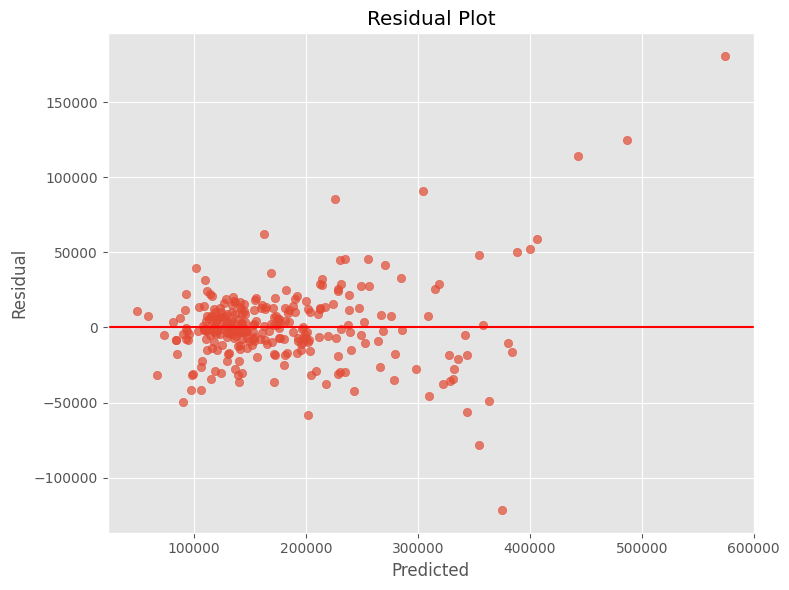

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    color="red"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.tight_layout()

plt.savefig(
    FIGURES / "residual_plot.png",
    dpi=300
)

plt.show()

Cross Validation

In [12]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(

    best_model,

    X_train,

    y_train,

    scoring="r2",

    cv=cv
)

print(scores)
print("Average R²:", scores.mean())

[0.90035003 0.78637731 0.82228041 0.90641284 0.89565718]
Average R²: 0.8622155547142029


Learning Curve

In [13]:
sizes, train_scores, valid_scores = learning_curve(

    best_model,

    X_train,

    y_train,

    cv=5,

    scoring="r2",

    train_sizes=np.linspace(0.1,1,10),

    n_jobs=-1
)

Plot Learning Curve

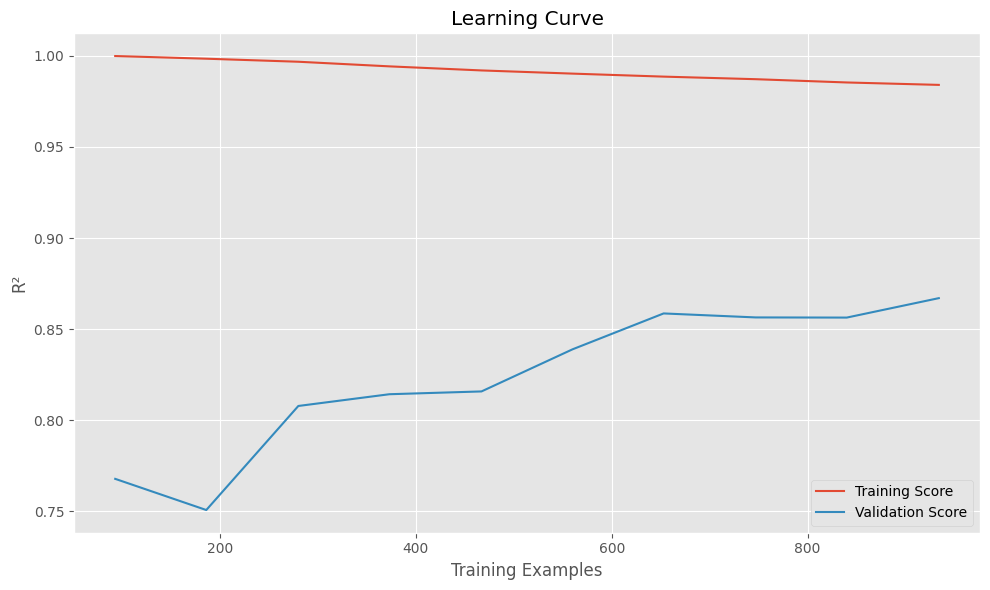

In [14]:
plt.figure(figsize=(10,6))

plt.plot(
    sizes,
    train_scores.mean(axis=1),
    label="Training Score"
)

plt.plot(
    sizes,
    valid_scores.mean(axis=1),
    label="Validation Score"
)

plt.legend()

plt.xlabel("Training Examples")

plt.ylabel("R²")

plt.title("Learning Curve")

plt.tight_layout()

plt.savefig(
    FIGURES / "learning_curve.png",
    dpi=300
)

plt.show()

Top Features

In [15]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)

importance.head(20)

,Feature,Importance
4,OverallQual,0.167410
26,GarageCars,0.158330
151,ExterQual_TA,0.084386
213,GarageFinish_Unf,0.064010
19,FullBath,0.031098
16,GrLivArea,0.030478
196,KitchenQual_TA,0.029456
111,RoofMatl_CompShg,0.028704
15,LowQualFinSF,0.024402
163,BsmtQual_TA,0.021371


Plot Top Features

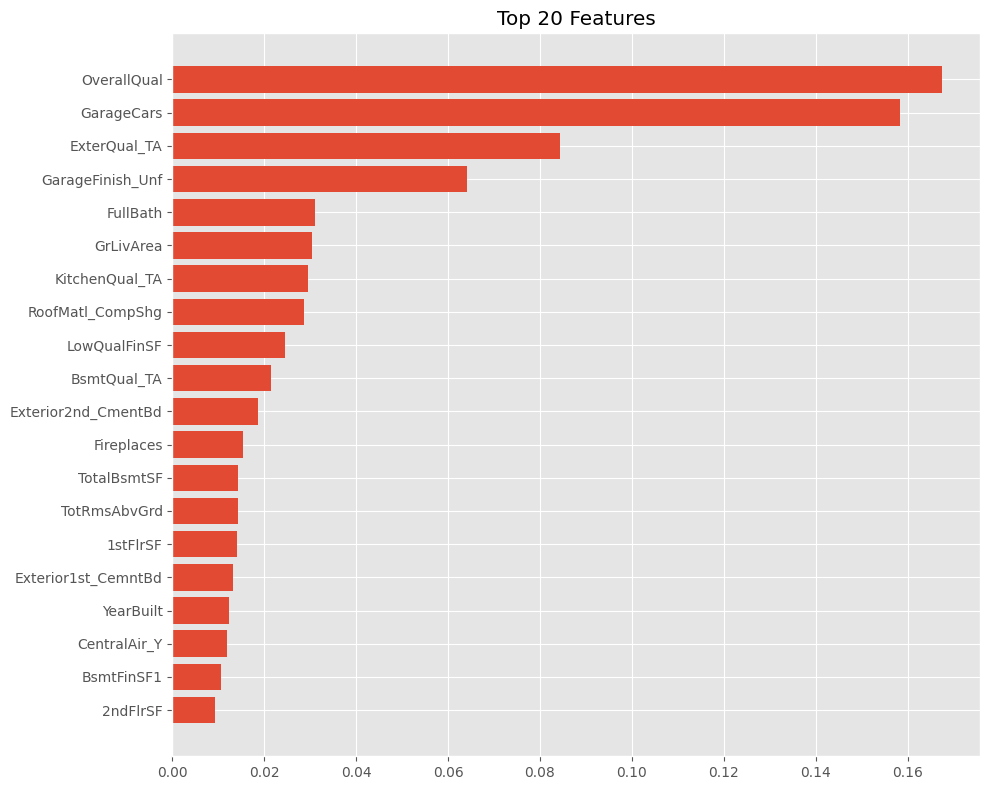

In [16]:
plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"][:20],

    importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Features")

plt.tight_layout()

plt.savefig(

    FIGURES / "top20_features.png",

    dpi=300
)

plt.show()

Save Feature Importance

In [17]:
importance.to_csv(

    REPORTS / "feature_importance.csv",

    index=False
)

Save Predictions

In [18]:
pred_df = pd.DataFrame({

    "Actual":y_valid,

    "Predicted":predictions,

    "Residual":residuals
})

pred_df.to_csv(

    REPORTS / "predictions.csv",

    index=False
)

Final Summary

In [19]:
print("="*50)
print("HOUSE PRICE PREDICTION PROJECT COMPLETE")
print("="*50)

print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"R²   : {r2:.4f}")

print("\nCross Validation R²")
print(scores.mean())

print("\nBest Model")

print(type(best_model).__name__)

print("="*50)

HOUSE PRICE PREDICTION PROJECT COMPLETE
RMSE : 26,397.78
MAE  : 16,499.98
R²   : 0.9092

Cross Validation R²
0.8622155547142029

Best Model
XGBRegressor
